# Simple Single Lens (with ARC) simulation with MeepSAT

`NOTE`: First, make sure to connect to the correctly installed version of MeepSAT's jupyter kernel 

In this tutorial, we will simulate a 2D Gaussian beam propagating through a plano-convex lens with anti-reflective (AR) coatings. By the end of this tutorial, you will understand how to:

- Configure simulation parameters in JSON format
- Defining a monochromatic source
- Define simple optical components like lenses and apertures
- Visualize and analyze the electromagnetic field evolution over time.
- Extract useful metrics like time averaged $\textbf{S}$ and $\textbf{E}$ field
- Comparing the far field results with the current industry standard softwares such as GRASP, CST

In [1]:
# Importing various Python libraries and MeepSAT modules
import sys
import os
import site
from pathlib import Path
import meep as mp
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import json

# Importing the MEEPSAT librarires
import meepsat.simulator as sim
import meepsat.meep_geometry as comp_meep
import meepsat.permittivity_components as comp_eps
import meepsat.stepfunctions as stepfunctions
import meepsat.json_to_script as json_to_script
import meepsat.field_analysis as mpsat_analysis
import meepsat.helpers as mpsat_helpers

# JSON file path representing mainly the different optical components parameters
json_file_path = 'auxilary_data/01_simple_single_lens_ARC/simple_single_lens_ARC.json'
data = mpsat_helpers.read_json(json_file_path)

# Some universal constants
c_mm_s = 299792458.0 * 1000.0  # Speed of light in mm/s (m/s -> mm/s)
# Frequency of the simulation
freq = 150.0  # Frequency in GHz
a = 1  # 1 meep unit = 1 mm
wvl = c_mm_s / (freq * 1e9)  # Wavelength in mm
freq_meep = 1.0 / (wvl * a)
print("freq (meep units):", freq_meep)

# Edit the freq in the JSON file 
data["sources"]["source1"]["frequecy"] = freq_meep

# Savepath: For storing the output generated during the simulation
savepath = f'auxilary_data/01_simple_single_lens_ARC/output_files/{freq}GHz'
os.makedirs(savepath, exist_ok=True)

Using MPI version 4.1, 1 processes
freq (meep units): 0.5003461427972281


Initialising the MeepSAT simulation object from the parameters stored in the JSON file

In [2]:
# Initialising MEEPSAT Simulation
cell_X, cell_Y, cell_Z = data["simulation"]['primary_params']['cell_size']['x'], data["simulation"]['primary_params']['cell_size']['y'], data["simulation"]['primary_params']['cell_size']['z'] # Cell Size without considering the PML thickness and its factor


# Initialize the simulation with the different parameters
mpsat_sim = sim.sim_init(sim_name= str(data["simulation"]["name"]),
                        cell_size= [cell_X, cell_Y, cell_Z], # [sx, sy, sz] in mm
                        smallest_freq= data["simulation"]['primary_params']['smallest_freq'], 
                        resolution= data["simulation"]['primary_params']['resolution'],
                        boundary_layer_type= data['boundary_layers']['boundary']['type'],
                        boundary_layer_size= data['boundary_layers']['boundary']['size'],
                        factor_dpml= data['boundary_layers']['boundary']['factor_dpml'])


Before creating the components, its very important to check if the mentioned resulution and PML boundary layer thickness is enough for our simulation OR not. In Meep FDTD, its recommended to have atleast 8-10 pixels for the smallest wavelength OR length scale present in your system. 

You can check the resolution and verify using `sim.check_resolution_and_pml`

In [3]:
# Checking resolution and PML thickness 
# This function will automatically check all the length scales and wavelength scales
data, mpsat_sim = sim.check_resolution_and_pml(
    data=data, 
    mpsat_sim=mpsat_sim,
    smallest_freq=data["simulation"]['primary_params']['smallest_freq'],
    highest_n=data["lenses"]["lens1"]["n_refr"]
)

# Print the simulation parameters
print("\nMEEPSAT SIMULATION PARAMETERS:")
mpsat_sim.print_simulation_parameters()


Highest refractive index provided:  1.525
Given PML thickness:  2
Given resolution:  8
Assuming the wavelength of the Source to be the largest wavelength present in the system and doing a sanity check on the PML thickness.
Smallest frequency provided:  0.25
Highest refractive index provided:  1.525
Highest refractive index provided:  1.525
Assuming the wavelength of the Source to be the largest wavelength present in the system and doing a sanity check on the PML thickness.
Smallest frequency provided:  0.25
Resolution criteria doesn't meet the criteria for the ARC layers. Increasing the resolution to meet the criteria.
Resolution criteria doesn't meet the criteria for the ARC layers. Increasing the resolution to meet the criteria.
All length scales of lenses in the simulation:  [0.51, 0.51]
All refractive indices of different components in the of lense in the simulation:  [1.23, 1.23]
Modified resolution:  15
Modified PML thickness:  2

MEEPSAT SIMULATION PARAMETERS:
Simulation name: s

Now let's add a Monochromatic Source 
- You can either follow the Source documentation mentioned in the ReadTheDocs documentation page

    OR

- Just use MeepSAT's built-in function to generate the source from the JSON file

In [4]:
source_list = []
exec(json_to_script.source_script(data))

Angle of the source:3.141592653589793 rad = 180 degrees
Additional arguments for the ContinuousSource:  {'start_time': 0, 'end_time': 1e+20}
Additional arguments for GaussianBeamSource:  {'beam_x0': Vector3<0.0, 0.0, 0.0>, 'beam_E0': Vector3<0.0, 0.0, 1.0>}
Gaussian beam source assembled!


Adding PML boundaries using MEEP

In [5]:
x_left_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.Low)
x_right_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.High)
y_down_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.Low)
y_up_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.High)

custom_boundary_layers = [x_left_boundary, x_right_boundary, y_down_boundary, y_up_boundary]

Now as we need to add a lot of complex structures (lenses, absorbers etc), we will define a empty epsilon map for this purpose. Its basically a 2D spatial discretization array of the simulation domain and the idea is to draw structure on this 2D array

In [6]:
size_x, size_y, size_z = mpsat_sim.cell_size[0], mpsat_sim.cell_size[1], mpsat_sim.cell_size[2]
res = int(mpsat_sim.resolution)  # Ensure resolution is an integer
# Create the epsilon map: total size of the simulation cell in all the axis multiplied by the resolution + 1
epsilon_map = np.ones((int((size_x)*res+1), 
                       int((size_y)*res+1)), dtype = 'float32')

Now as we did for the Source, we will use MeepSAT built in function for defining lenses and aperture

In [7]:
# Adding lens (if given)
exec(json_to_script.add_lens(data))

# Adding aperture (if given)
exec(json_to_script.add_aperture(data))

Saving epsilon map to HDF5 file...
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] added to the list of components created using the epsilon functions!
HDF5 file written to /Users/asheshak_oaslak/Phd_work/MeepSAT/output_files/single_lens_testing_ARC_epsilon_map.h5
Aperture stop created with orientation: vertical
type material:  Medium()
Aperture stop created (vertical): Up size=Vector3<1.0, 3.0, 0.0>, Down size=Vector3<1.0, 3.0, 0.0>
Centers: Up=Vector3<-59.5, 26.5, 0.0>, Down=Vector3<-59.5, -26.5, 0.0>
<meep.geom.Block object at 0x16bbb6f90> added to the list of components created using the MEEP functions!
<meep.geom.Block object at 0x16c238190> added to the list of components created using the MEEP functions!


Since this system is system at x=0 plane, we will use MEEP's Mirror symmetry

In [8]:
symmetries = [mp.Mirror(mp.Y, phase=+1)] 

Now defining the Meep Simulation Object

In [9]:
simulation = mp.Simulation(
    cell_size=mpsat_sim.cell,
    sources=source_list,
    resolution=mpsat_sim.resolution,
    boundary_layers=custom_boundary_layers,
    geometry=mpsat_sim.meep_geometry,
    epsilon_input_file = data["output"]["savepath"]["path"] + data["output"]["epsilon_h5_file"]["filename"] +"_epsilon_map" + ".h5",
    symmetries = symmetries,
    force_complex_fields= True)

simulation.use_output_directory(savepath)

'auxilary_data/01_simple_single_lens_ARC/output_files/150.0GHz'

Let's run the simulation briefly to store the epsilon map and visualise the permittivity map

-----------
Initializing structure...
read in 2431x841x1 epsilon-input-file "../output_files/single_lens_testing_ARC_epsilon_map.h5"
Halving computational cell along direction y
time for choose_chunkdivision = 0.001413 s
read in 2431x841x1 epsilon-input-file "../output_files/single_lens_testing_ARC_epsilon_map.h5"
Working in 2D dimensions.
Computational cell is 162 x 56 x 0 with resolution 15
     block, center = (-59.5,26.5,0)
          size (1,3,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     block, center = (-59.5,-26.5,0)
          size (1,3,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
time for set_epsilon = 1.10737 s
-----------
Meep: using complex fields.
Meep: using output directory 'auxilary_data/01_simple_single_lens_ARC/output_files/150.0GHz'


FloatProgress(value=0.0, description='0% done ', max=0.0)

run 0 finished at t = 0.0 (0 timesteps)


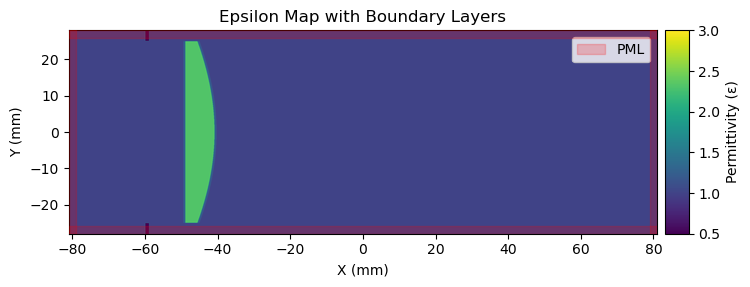

Epsilon plot saved to: auxilary_data/01_simple_single_lens_ARC/output_files/150.0GHz/geometry_plot.png
Epsilon data saved to: auxilary_data/01_simple_single_lens_ARC/output_files/150.0GHz/geometry_plot.h5


In [10]:
sim.plot_and_save_epsilon(
    simulation=simulation,
    savepath=savepath,
    filename_prefix="geometry_plot",
    epsilon_data_name="epsilon",
    size_x=size_x,
    size_y=size_y,
    vmin=0.5,
    vmax=3,
    cmap='viridis',
    figsize=(8, 4),
    dpi=300,
    show_plot= True
)

Now let's set the different run time parameters:
- Animation

    `stepfunctions.set_animation_params(...)`
    - Configures how the simulation will be visualized as an animation
        - `image_every`: Frequency of field snapshots (e.g., every N timesteps)
        - `Nfps`: Frames per second for the output video
        - `anim_file_name`: Output path and filename for the MP4 movie

- Field Parameters

    `stepfunctions.set_field_params(...)`
    - Defines spatial and storage parameters for electromagnetic field data
        - `size_x`, `size_y`: Physical dimensions of the simulation domain
        - `savepath`: Directory where field data will be stored
        - `downsampling_factor_x/y`: Reduces data resolution for storage (e.g., keep every Nth point)

- Runtime Parameters

    `runtime_params = sim.calculate_runtime_parameters(...)`
    - Computes temporal simulation parameters for field extraction based on the source frequency
        - `source_freq`: Operating frequency (extracted from JSON with a typo "frequecy")
        - `total_time`: Total simulation duration
        - `animation_timestep`: Time interval between field captures
        - `points_per_period`: Temporal resolution (10 points per wavelength period)
        - `extraction_offset`: Buffer time before field extraction begins

In [ ]:
# Set the stepfunctions parameters
# Animation Parameters
stepfunctions.set_animation_params(anim_params= {'image_every': data["output"]["animation_options"]["image_every"], 
                                              'Nfps': data["output"]["animation_options"]["Nfps"], 
                                              'anim_file_name': savepath + "/"+ data["output"]["animation_options"]["movie_name"] + ".mp4"})
# Field Parameters
stepfunctions.set_field_params(field_params= {'size_x': size_x,
                                              'size_y': size_y,
                                              'savepath': savepath,
                                              'downsampling_factor_x': data["output"]["animation_options"]["downsample_x"],
                                              'downsampling_factor_y': data["output"]["animation_options"]["downsample_y"]})

# Runtime parameters
runtime_params = sim.calculate_runtime_parameters(
    source_freq=float(data["sources"]["source1"]["frequecy"]),
    total_time= 400,
    animation_timestep = data["output"]["animation_options"]["image_every"],
    points_per_period=20,
    extraction_offset=10
)

Now we are all set to run the simulation!!

In [ ]:
simulation.run(mp.at_every(runtime_params["animation_timestep"], stepfunctions.Ez2_dB),
               mp.after_time(runtime_params["t0"], mp.at_every(runtime_params["dt"], stepfunctions.accumulate_efield_and_hfield)),
               mp.at_end(stepfunctions.save_animation),
               mp.at_end(stepfunctions.save_accumulated_fields),
               mp.at_end(stepfunctions.extract_xyzw),
               until = runtime_params["total_time"])

print("Simulation completed.")                                                 

# #~ ---------------------------------------------

# Save the final edited JSON data
with open(data["output"]["savepath"]["path"] + data["simulation"]["name"] + "_simulation_data.json", "w") as f:
    json.dump(data, f, indent=2)
print(f"Simulation parameters saved to: {data['output']['savepath']['path']}{data['simulation']['name']}_simulation_data.json")

# Post Simulation Analysis

Now we will be extracting the following information from the post-processed data:
1) Verifying the aperture profile and the corresponding far field beams with industry standard softwares such as CST and GRASP.
2) Calculating the poynting vector $\textbf{S}$ from the $\textbf{E}$ and $\textbf{H}$ fields.
3) Analysing the Scalar Product between the Poynting Vector components of time-forward and time-reverse simulations.

First, let's write some functions to properly extract the E-field and H-field depending on the different frequencies!

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

def load_fields(basepath, filename):
    # Construct the full path to the file
    filepath = os.path.join(basepath, filename)
    # Load the fields stored in npz files
    data = np.load(filepath)

    return data

basepath = os.path.join(savepath)
e_filename = 'efield_timeavg.npz'
h_filename = 'hfield_timeavg.npz'
xyzw_filename = 'xyzw.npz'
e_data = load_fields(basepath, e_filename)
h_data = load_fields(basepath, h_filename)
xyzw_data = load_fields(basepath, xyzw_filename)
print("E-field data keys:", e_data.files)
print("H-field data keys:", h_data.files)
print("XYZW data keys:", xyzw_data.files)


Now since the 2D simulations are done in TE mode polarization, so only the Ez, Hx, Hy component survives.

In [ ]:
# TE component (Ez, Hx, Hy)
ez = e_data['ez_real'] + 1j * e_data['ez_imag']
hx = h_data['hx_real'] + 1j * h_data['hx_imag']
hy = h_data['hy_real'] + 1j * h_data['hy_imag']

Now lets calculate the corresponding poynting vector $\textbf{S}$. The Poynting vector components in TE mode are:

$S_x = -E_z \cdot H_y^*$

$S_y = E_z \cdot H_x^*$

In [ ]:
# S vector components for TE mode
sx = -ez * np.conj(hy)
sy = ez * np.conj(hx)
sx_mag = np.abs(sx)
sy_mag = np.abs(sy)
s_total = np.sqrt(sx_mag**2 + sy_mag**2)
s_total_db = 10 * np.log10(s_total / np.max(s_total) + 1e-20)  # in dB
# efield magnitude
ez_power = np.abs(ez)**2
ez_power_db = 10 * np.log10(ez_power / np.max(ez_power) + 1e-20)  # in dB

Let's plot the Poynting vector magnitude and efield power

In [ ]:
def plot_field(simname, field_db, title, filename, xcoords, ycoords, freq,
               vmin=-40, vmax=0, 
               savepath= os.path.join('./../processed_data/'),
                show_plots=True):
    import matplotlib.pyplot as plt
    plt.style.use('default')
    
    plt.figure(figsize=(8, 6))
    plt.imshow(field_db.T, extent=(xcoords[0], xcoords[-1], ycoords[0], ycoords[-1]),
               origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
    plt.colorbar(label='dB')
    plt.title(title)
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')

    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        # Save as a svg file as well for publication
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plots:
        plt.show()

# E-field plot
plot_field(simname = 'simple_single_lens_ARC', 
            field_db=ez_power_db, 
            title='E-field Magnitude (dB)', 
            filename='ez_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'],
            freq=freq)
# S-vector plot
plot_field(simname = 'simple_single_lens_ARC', 
            field_db= s_total_db, 
            title='Poynting Vector Magnitude (dB)', 
            filename='s_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'],
            freq=freq)

# Far Field Beam comparision with CST and GRASP!

In the current version of the MeepSAT, we extract the Far Field Beam profile using the [Fraunhofer diffraction](https://en.wikipedia.org/wiki/Fraunhofer_diffraction_equation) formula, where the far field is basically the fourier transform of the fields at the aperture. In the near future, we will also have the capabilties in MeepSAT to extract the far field beam using the spherical decomposition approach. 

First we will define the various dictionaries and file paths to the GRASP and CST simulations data followed by defining some customisable functions to read the aperture GRASP and CST simulated datasets. 

In [ ]:
import meepsat.field_analysis as analysis

#FOR GRASP
def load_grasp_aperture_data(aperture_file, freq_label):
    print(f"Loading GRASP aperture data from: {aperture_file} for frequency label: {freq_label}")
    with h5py.File(aperture_file, 'r') as f:
        print("Keys in the HDF5 file:", list(f.keys()))
        print(f"Keys in the frequency group '{freq_label}':", list(f[freq_label].keys()))
        aperture_data = {
            'Ex': f[freq_label]['Ex'][:],
            'Ey': f[freq_label]['Ey'][:],
            'Ez': f[freq_label]['Ez'][:],
            'x': f[freq_label]['x'][:],
            'y': f[freq_label]['y'][:],
        }
        print("GRASP resolution (y)", analysis.calculate_grasp_resolution(aperture_data['y']))
    return aperture_data

def load_grasp_farfield_data(farfield_file, freq_label):
    print(f"Loading GRASP far field data from: {farfield_file} for frequency label: {freq_label}")
    with h5py.File(farfield_file, 'r') as f:
        print("Keys in the HDF5 file:", list(f.keys()))
        print(f"Keys in the frequency group '{freq_label}':", list(f[freq_label].keys()))
        Eco = f[freq_label]['Ex'][:]
        Ecx = f[freq_label]['Ey'][:]
        x = f[freq_label]['x'][:]
        
        Eco_dB = 10 * np.log10(np.abs(Eco)**2 / np.max(np.abs(Eco)**2))
        center_y, center_x = np.array(Eco_dB.shape) // 2
        
        return {
            'angle': x,
            'power_dB': Eco_dB[:, center_x],
        }

# FOR CST
def load_cst_data(ey_file, s_file, plot_label = 'CST TE'):
    # Load Ey data by using pandas
    import pandas as pd
    ey_data = pd.read_csv(ey_file, delim_whitespace=True, skiprows=3, names=['Y', 'Re(Ey)', 'Im(Ey)'])
    s_mag_data = pd.read_csv(s_file, delim_whitespace=True, skiprows=3, names=['Y', 'S_Mag_linear'])

    print(f"file found: {ey_file}, {s_file}")

    data_dict = {
        'efield': ey_data,
        's_mag': s_mag_data,
        'plot_label': plot_label
    }

    return data_dict

# ========================= GRASP aperture field data =============================
base_grasp_data_dir = Path('auxilary_data/01_simple_single_lens_ARC/GRASP_data/50mm_lens_sim')

"""
Define GRASP files in a structured way for extracting Aperture 
and farfield data (calculated within GRASP using spherical decomposition) 
for different simulation configurations (PO noARC, MoM with ARC, MoM noARC)
"""

grasp_files = {
    'PO_noARC': {
        'aperture': 'apertureField_PO.h5',
        'farfield': 'far_field_beams_PO.h5',
        'label': 'GRASP PO noARC'
    },
    'MoM_ARC': {
        'aperture': 'apertureField_MoM_AR.h5',
        'farfield': 'far_field_beams_MoM_AR.h5',
        'label': 'GRASP MoM with ARC'
    },
    'MoM_noARC': {
        'aperture': 'apertureField_MoM_noAR.h5',
        'farfield': 'far_field_beams_MoM_noAR.h5',
        'label': 'GRASP MoM noARC'
    }
}

# Add full paths
for key in grasp_files:
    grasp_files[key]['aperture'] = str(base_grasp_data_dir / f'50mm_lens_90120150GHz_{grasp_files[key]["aperture"]}')
    grasp_files[key]['farfield'] = str(base_grasp_data_dir / f'50mm_lens_90120150GHz_{grasp_files[key]["farfield"]}')
    

# Load all GRASP data
grasp_aperture_data = {}
grasp_farfield_data = {}
freq_to_analyse = str(int(freq))
c = 2.998e+11  # Speed of light in mm/s
wvl_meep = c / (freq * 1e9)  # Wavelength in mm
print(f"Frequency to analyse: {freq_to_analyse} GHz, corresponding wavelength: {wvl_meep:.2f} mm")

for key, files in grasp_files.items():
    aperture_data = load_grasp_aperture_data(files['aperture'], freq_to_analyse)
    aperture_data['plot_label'] = files['label'].replace('GRASP ', '')
    grasp_aperture_data[key] = aperture_data
    
    farfield_data = load_grasp_farfield_data(files['farfield'], freq_to_analyse)
    farfield_data['plot_label'] = files['label']
    grasp_farfield_data[key] = farfield_data

# ========================= CST APERTURE DATA =============================
# TE Ey file format: 120mm_TE_Ey_ReIm_arc_{}_GHz.txt.format(freq)
# TM Ey file format: 120mm_TM_Ey_ReIm_arc_{}_GHz.txt.format(freq)
# TE S file format: 120mm_TE_S_Mag_arc_{}_GHz.txt.format(freq)
# TM S file format: 120mm_TM_S_Mag_arc_{}_GHz.txt.format(freq)

TE_Ey_data_file = Path('auxilary_data/01_simple_single_lens_ARC/CST_data/ARC/Field data along both X and Y slices 120mm focus (TM and TE pols)/120mm_TE_Ey_ReIm_arc_{}_GHz.txt'.format(freq_to_analyse))
TE_S_data_file = Path('auxilary_data/01_simple_single_lens_ARC/CST_data/ARC/Field data along both X and Y slices 120mm focus (TM and TE pols)/120mm_TE_S_Mag_arc_{}_GHz.txt'.format(freq_to_analyse))

CST_data_with_ARC = load_cst_data(TE_Ey_data_file, TE_S_data_file, plot_label='CST TE (with ARC)')


Now we will be calculating the far field beam from the aperture field profile from GRASP, CST and MeepSAT!

In [ ]:
"""
zeropad controls the zero-padding applied to the aperture field 
before computing the far-field beam pattern using FFT (Fast Fourier Transform).

Purpose:
- Increases the frequency resolution in the far-field domain
- Provides smoother interpolation of the far-field radiation pattern
- Higher values give finer angular resolution but increase computation time

How it works:
The aperture field is padded with zeros to (original_length of efield * zeropad) points
before FFT, effectively increasing the number of far-field angle samples.
"""
zeropad = 15

# Aperture radius (in mm)
# Defines the physical extent of the aperture used for far-field calculation
aperture_radius = data["apertures"]["aperture1"]["diameter"]/2

Now lets extract the aperture slice E-field for GRASP MoM, CST FIT and MeepSAT FDTD

In [ ]:
# GRASP (Ex is the dominant component for TE mode, and we are ignoring Ez and Ey for simplicity)
aperture_slice_grasp_mom_ez = 0
aperture_slice_grasp_mom_ey = 0
aperture_slice_grasp_mom_ex = grasp_aperture_data['MoM_ARC']['Ex'][:, grasp_aperture_data['MoM_ARC']['Ex'].shape[1] // 2]
aperture_slice_grasp_mom = np.abs(aperture_slice_grasp_mom_ez + aperture_slice_grasp_mom_ex + aperture_slice_grasp_mom_ey)
# Set everything else to NaN except the values within the aperture diameter
aperture_slice_grasp_mom = np.where(np.abs(grasp_aperture_data['MoM_ARC']['y']) <= aperture_radius, aperture_slice_grasp_mom, np.nan)
# Remove NaN indices from both the power and the corresponding y-coordinates
valid_indices_grasp = ~np.isnan(aperture_slice_grasp_mom)
aperture_slice_grasp_mom = aperture_slice_grasp_mom[valid_indices_grasp]
y_coords_grasp = grasp_aperture_data['MoM_ARC']['y'][valid_indices_grasp]
aperture_slice_grasp_mom = aperture_slice_grasp_mom/np.max(aperture_slice_grasp_mom)
aperture_slice_grasp_mom_dB = 10 * np.log10(aperture_slice_grasp_mom + 1e-20)  # in dB

# CST (Ey is the dominant component for TE mode simulations done with CST)
aperture_slice_cst = np.abs(CST_data_with_ARC['efield']['Re(Ey)'] + 1j*CST_data_with_ARC['efield']['Im(Ey)'])
# Set everything else to NaN except the values within the aperture diameter
aperture_slice_cst = np.where(np.abs(CST_data_with_ARC['efield']['Y']) <= aperture_radius, aperture_slice_cst, np.nan)
# Remove NaN indices from both the power and the corresponding y-coordinates
valid_indices_cst = ~np.isnan(aperture_slice_cst)
aperture_slice_cst = aperture_slice_cst[valid_indices_cst]
y_coords_cst = CST_data_with_ARC['efield']['Y'][valid_indices_cst]
aperture_slice_cst = np.array(aperture_slice_cst/np.max(aperture_slice_cst))
aperture_slice_cst_dB = 10 * np.log10(aperture_slice_cst + 1e-20)  # in dB


# MeepSAT (Ez is the dominant component for TE mode in MeepSAT simulations)
# Extract a 1D slice at the aperture location (x=-60 mm)
x_index = (np.abs(xyzw_data['x_coords'] - (data["apertures"]["aperture1"]["pos_x"]))).argmin()
aperture_slice_meepsat = ez[x_index, :]  # Extract 1D slice at x=-60
aperture_slice_meepsat = np.abs(aperture_slice_meepsat)
# Set everything else to NaN except the values within the aperture diameter
aperture_slice_meepsat = np.where(np.abs(xyzw_data['y_coords']) <= aperture_radius, aperture_slice_meepsat, np.nan)
# Remove NaN indices from both the power and the corresponding y-coordinates
valid_indices = ~np.isnan(aperture_slice_meepsat)
aperture_slice_meepsat = aperture_slice_meepsat[valid_indices]
y_coords_meepsat = xyzw_data['y_coords'][valid_indices]
aperture_slice_meepsat = aperture_slice_meepsat/np.max(aperture_slice_meepsat)  # Normalize the power for better comparison
aperture_slice_meepsat_dB = 10 * np.log10(aperture_slice_meepsat + 1e-20)  # in dB

Let's plot the profiles in linear scale to visualise

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('default')

# Plot the efield profiles at the aperture for comparision
plt.figure(figsize=(8, 6))

# MeepSAT aperture slice (normalized)
plt.plot(y_coords_meepsat, aperture_slice_meepsat, label='MEEPSAT FDTD')
# GRASP MOM aperture slice (normalized)
plt.plot(y_coords_grasp, aperture_slice_grasp_mom, label='GRASP MoM')
# CST aperture slice (normalized)
plt.plot(y_coords_cst, aperture_slice_cst, label='CST FIT')

plt.axvline(x=aperture_radius, color='blue', linestyle='--', label='Aperture Edge +')
plt.axvline(x=-aperture_radius, color='red', linestyle='--', label='Aperture Edge -')
plt.title('E-field Profile at Aperture')
plt.xlabel('Y Coordinate (mm)')
plt.ylabel('Normalized E-field Magnitude (linear scale)')
plt.grid()
plt.legend()

# Save the figure 
save_dir = os.path.join('./../processed_data', 'simple_single_lens_ARC', f'{freq}GHz')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'aperture_efield_comparison.png'), dpi=300, bbox_inches='tight')

# Save as a svg file for better quality in publications
plt.savefig(os.path.join(save_dir, 'aperture_efield_comparison.svg'), dpi=300, bbox_inches='tight')

plt.show()

Now lets calculate the far field using `analysis.meepsat_farfield` which basically calculates the FFT of the fields at the aperture and visualise the results.

In [ ]:
meepsat_farfield_dict = analysis.meepsat_farfield(efield= aperture_slice_meepsat,
             coords= y_coords_meepsat,
             wavelength= wvl_meep,
             resolution= mpsat_sim.resolution,
             zero_pad_beam=15,
             plot_label='MEEPSAT FDTD')

grasp_MOM_fft_dict = analysis.meepsat_farfield(efield= aperture_slice_grasp_mom,
             coords= y_coords_grasp,
             wavelength= wvl_meep,
             resolution= analysis.calculate_grasp_resolution(y_coords_grasp),
             zero_pad_beam=15,
             plot_label='GRASP MoM')

cst_fit_dict = analysis.meepsat_farfield(efield= aperture_slice_cst,
             coords= y_coords_cst,
             wavelength= wvl_meep,
             resolution= analysis.calculate_grasp_resolution(y_coords_cst),
             zero_pad_beam=15,
             plot_label='CST FIT')

import matplotlib.pyplot as plt
plt.style.use('default')

# Plot the farfield patterns for comparison
plt.figure(figsize=(8, 6))
plt.plot(meepsat_farfield_dict['angle'], meepsat_farfield_dict['power_dB'], label= meepsat_farfield_dict['plot_label'])
plt.plot(grasp_MOM_fft_dict['angle'], grasp_MOM_fft_dict['power_dB'], label=grasp_MOM_fft_dict['plot_label'])
plt.plot(cst_fit_dict['angle'], cst_fit_dict['power_dB'], label=cst_fit_dict['plot_label'])
plt.xlabel('Angle (degrees)')
plt.ylabel('Power (dB)')
plt.xlim(0, 20)
plt.ylim(-60,0)
plt.legend()

# Save the figure
save_dir = os.path.join('./../processed_data', 'simple_single_lens_ARC', f'{freq}GHz')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'farfield_comparison.png'), dpi=300, bbox_inches='tight')

# Save as a svg file for better quality in publications
plt.savefig(os.path.join(save_dir, 'farfield_comparison.svg'), dpi=300, bbox_inches='tight')

plt.show()

If for some reason, you want to run it using mpirun and bash script, there is an example provided [here](https://github.com/aa16oaslak/MeepSAT/tree/main/examples/HPC_Tutorial/time-reverse/01_simple_single_lens_ARC)